# Multiclass Ensemble Model
Combines a Random Forest, Xgboost and Lightgbm model to predict crops

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit
from sklearn.cluster import KMeans
from sklearn.model_selection import RandomizedSearchCV

# Load dataset and drop missing values
df = pd.read_csv('Crop_Features.csv')
df = df.dropna()

# Map class codes to names
class_mapping = {
    '1': 'Natural Vegetation',
    '2': 'Bare Soil / Rocky',
    '3': 'Water / Snow',
    '4': 'Built-up / Residential',
    '5': 'Agriculture'
}
df['class_name_mapped'] = df['class'].astype(str).map(class_mapping)
class_names = list(class_mapping.values())

# Convert to zero array to ensure compatibility
y = df['class'] - 1

### Spatial Blocking
Group sample points geographically using coordinates. Cheap way to deal with spatial autocorrelation by making sure close points can't appear in train and test sets

In [2]:
# Create spatial blocks based on coordinates
coords = df[['latitude', 'longitude']]
kmeans = KMeans(n_clusters=100, random_state=42)
df['spatial_block'] = kmeans.fit_predict(coords)

# Drop non feature columns
columns_to_drop = ['class', 'class_name', 'class_name_mapped', 'year_id', '.geo', 'system:index', 'latitude', 'longitude', 'spatial_block']
columns_to_drop = [col for col in columns_to_drop if col in df.columns]
X = df.drop(columns=columns_to_drop)

# Split data 
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df['spatial_block']))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

### Random Forest Model


Starting Random Forest Training
Best RF Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 20}



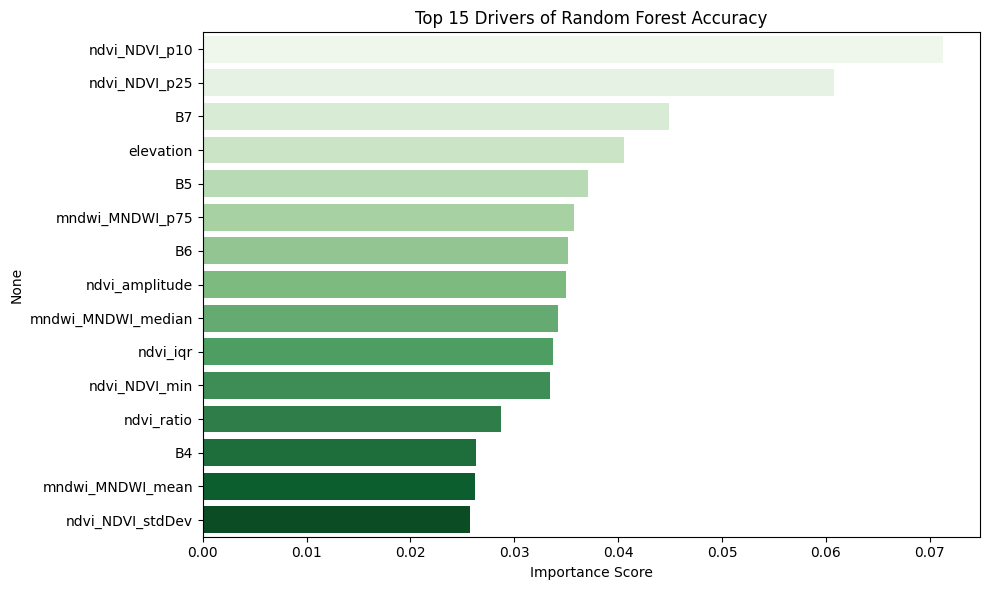

In [3]:
# Define search space
rf_grid = {
    'n_estimators': [100, 250, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

print("Starting Random Forest Training")
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=rf_grid, n_iter=10, cv=3, scoring='accuracy', random_state=42, n_jobs=-1
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("Best RF Parameters: " + str(rf_search.best_params_) + "\n")

# Plot feature importances
rf_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importances, y=rf_importances.index, hue=rf_importances.index, palette='Greens', legend=False)
plt.title('Top 15 Drivers of Random Forest Accuracy')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Xgboost Model

Starting XGBoost Training
Best XGB Parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.1}



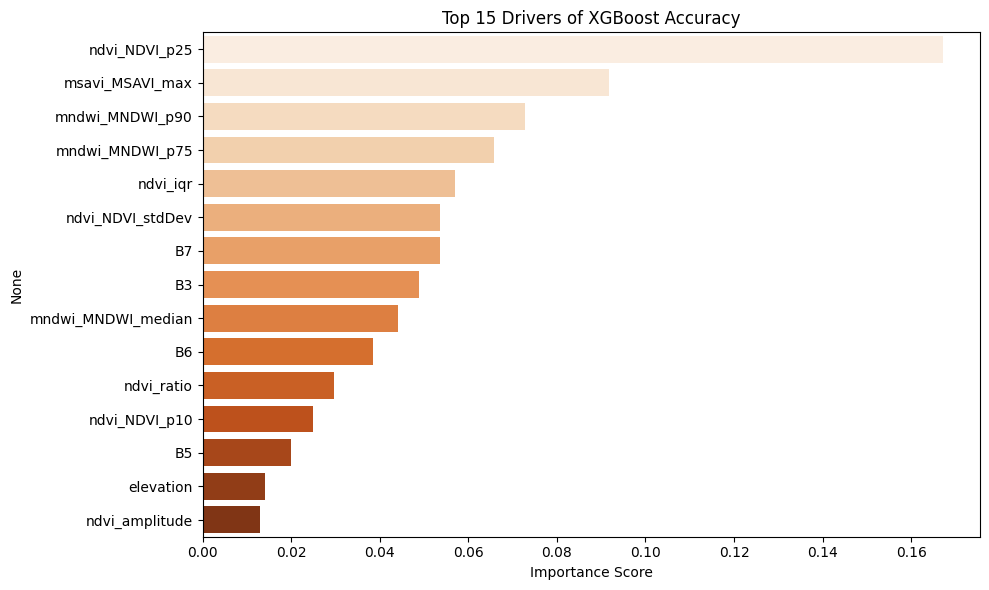

In [4]:
# Define search space
xgb_grid = {
    'n_estimators': [100, 250, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

print("Starting XGBoost Training")
xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    param_distributions=xgb_grid, n_iter=10, cv=3, scoring='accuracy', random_state=42, n_jobs=-1
)

xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

print("Best XGB Parameters: " + str(xgb_search.best_params_) + "\n")

# Plot feature importances
xgb_importances = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_importances, y=xgb_importances.index, hue=xgb_importances.index, palette='Oranges', legend=False)
plt.title('Top 15 Drivers of XGBoost Accuracy')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Lightgbm Model

Starting LightGBM Training
Best LGBM Parameters: {'num_leaves': 50, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1}



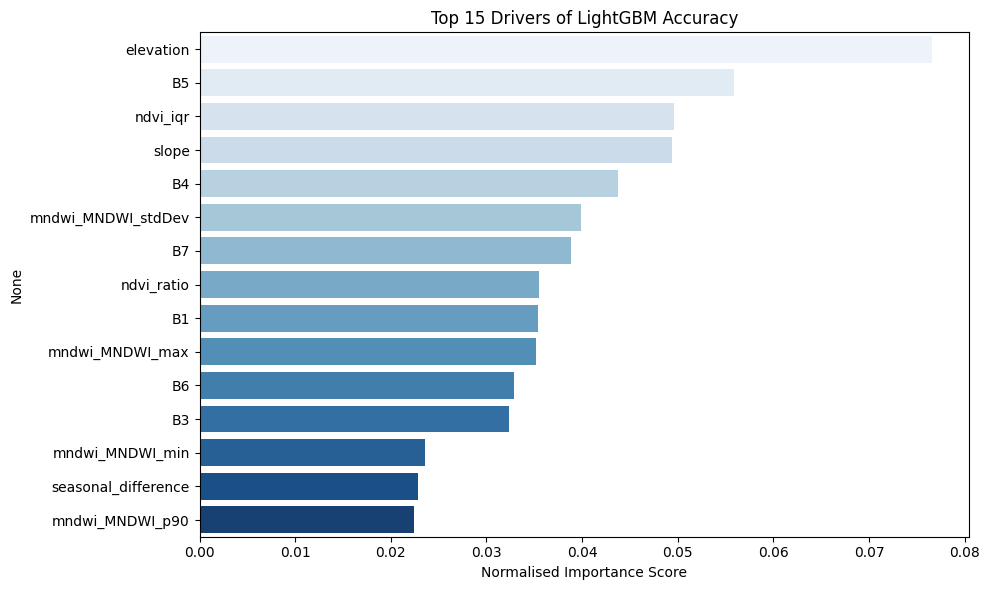

In [5]:
# Define search space
lgbm_grid = {
    'n_estimators': [100, 250, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'num_leaves': [31, 50, 70]
}

print("Starting LightGBM Training")
lgbm_search = RandomizedSearchCV(
    LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=lgbm_grid, n_iter=10, cv=3, scoring='accuracy', random_state=42, n_jobs=-1
)

lgbm_search.fit(X_train, y_train)
best_lgbm = lgbm_search.best_estimator_

print("Best LGBM Parameters: " + str(lgbm_search.best_params_) + "\n")

# Plot feature importances
lgbm_raw = pd.Series(best_lgbm.feature_importances_, index=X.columns)
lgbm_importances = (lgbm_raw / lgbm_raw.sum()).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=lgbm_importances, y=lgbm_importances.index, hue=lgbm_importances.index, palette='Blues', legend=False)
plt.title('Top 15 Drivers of LightGBM Accuracy')
plt.xlabel('Normalised Importance Score')
plt.tight_layout()
plt.show()

## Ensemble Model
Ensemble the models together to get the best combined performance

Training final ensemble model

Ensemble Spatial Accuracy: 95.0%

Classification Report:
                        precision    recall  f1-score   support

    Natural Vegetation       0.88      0.97      0.92       149
     Bare Soil / Rocky       0.99      0.95      0.97       241
          Water / Snow       0.93      0.93      0.93        14
Built-up / Residential       0.95      0.92      0.94       278
           Agriculture       0.96      0.96      0.96       357

              accuracy                           0.95      1039
             macro avg       0.94      0.95      0.94      1039
          weighted avg       0.95      0.95      0.95      1039



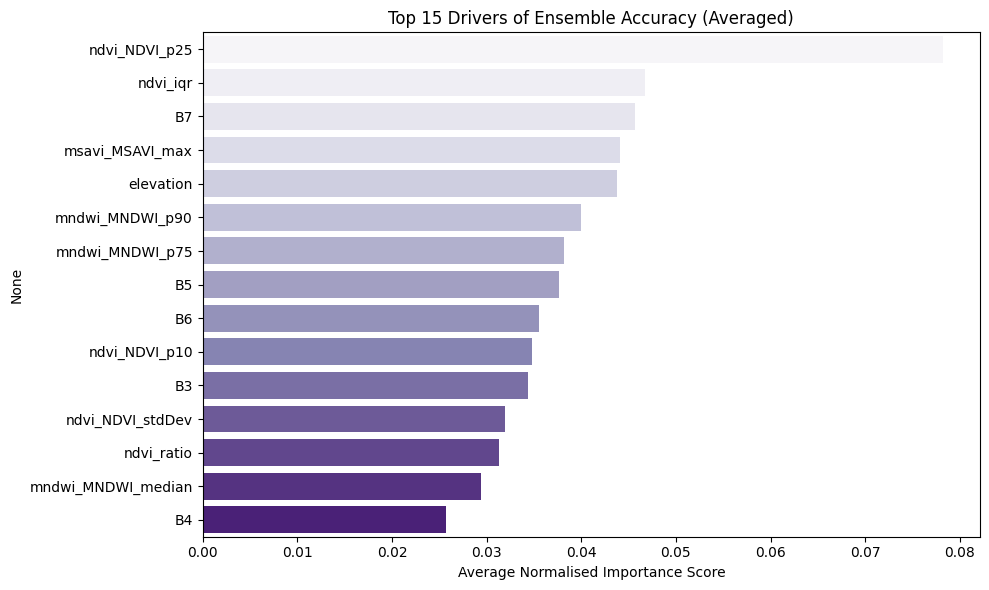

In [6]:
# Create the ensemble
print("Training final ensemble model")

ensemble_model = VotingClassifier(
    estimators=[
        ('Random Forest', best_rf),
        ('XGBoost', best_xgb),
        ('LightGBM', best_lgbm)
    ],
    voting='soft',
    n_jobs=-1
)

# Train model
ensemble_model.fit(X_train, y_train)

# Generate predictions 
y_pred = ensemble_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\nEnsemble Spatial Accuracy: " + str(round(accuracy * 100, 2)) + "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Retrieve feature importances
rf_raw = pd.Series(best_rf.feature_importances_, index=X.columns)
xgb_raw = pd.Series(best_xgb.feature_importances_, index=X.columns)
lgbm_raw = pd.Series(best_lgbm.feature_importances_, index=X.columns)

# Normalise all values
rf_norm = rf_raw / rf_raw.sum()
xgb_norm = xgb_raw / xgb_raw.sum()
lgbm_norm = lgbm_raw / lgbm_raw.sum()

# Calculate average importance
ensemble_importances = (rf_norm + xgb_norm + lgbm_norm) / 3.0
top_importances = ensemble_importances.sort_values(ascending=False).head(15)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances, y=top_importances.index, hue=top_importances.index, palette='Purples', legend=False)
plt.title('Top 15 Drivers of Ensemble Accuracy (Averaged)')
plt.xlabel('Average Normalised Importance Score')
plt.tight_layout()
plt.show()

### Visualisation

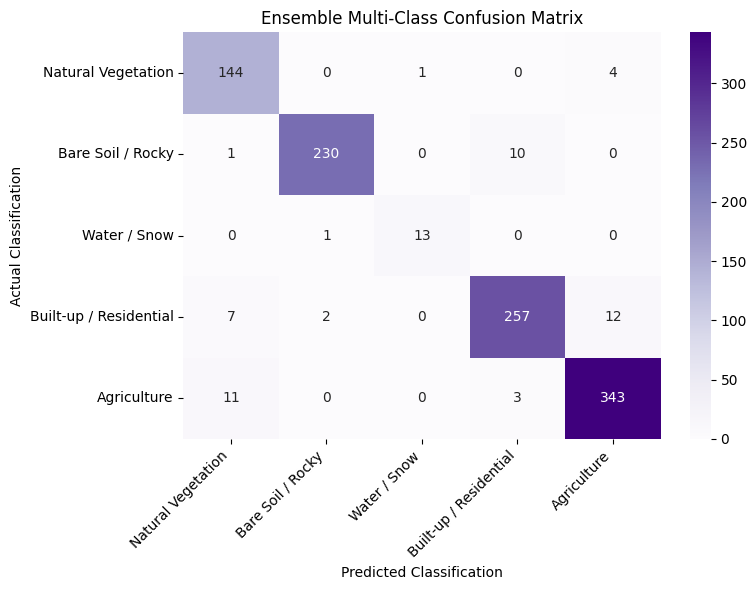

In [7]:
# Plot spatial confusion matrix for the ensemble
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.title('Ensemble Multi-Class Confusion Matrix')
plt.ylabel('Actual Classification')
plt.xlabel('Predicted Classification')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()